In [11]:
import requests

import pandas as pd
import geopandas as geopd

from shapely import Point

import matplotlib.pyplot as plt

from tqdm import tqdm

plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')

In [2]:
pd.options.display.max_columns = 30
pd.options.display.min_rows = 20
pd.options.display.max_rows = 30

In [3]:
def dict_list_to_df(values):
    """ Used for parsing the request
    """
    df = pd.DataFrame(columns=list(values[0].keys()))
    for item in values:
        new = pd.DataFrame([item])
        df = pd.concat([df, new], ignore_index=True)
    return df

# Fetching the places where water level is being measured. This will be used to to query flow data later.

In [4]:
url = "https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Paikka?$filter=Virtaama%2Fany(x%3A%20x%2FAika%20le%20datetime%272024-09-12T04%3A50%3A43.910Z%27)"


places = pd.DataFrame()
while True: # The length of data is unkown, so we continue to end and break
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.json()
        keys = content.keys()
    else:
        print(f"Error with request from url {url}, error code {response.status_code}")
    
    values = content['value']
    places = pd.concat([places, dict_list_to_df(values)], ignore_index=True)
    # is there still content left?
    if 'odata.nextLink' in keys:
        url = content['odata.nextLink']
    else:
        break

# Dictionnary
## Skipping translattion of some columns because they only relevant for Finnish base maps, or are mostly relevant to Finnish authorities

- Paikka_Id: place id
- Suure_Id: attribute id (2==Q, which should be all of the entries)
- H_Kunta_id: municipality id
- KuntaNimi: municipality name
- Nro: number of the gauge
- Nimi: Name of the gauge
- KoordLat: Latitude (epsg 4326)
- KoordLong: Longitude (epsg 4326)
- KoordErTmPohj: northing, ETRS-TM35FIN (epsg 3067)
- KoordErTmIta: easting, ETRS-TM35FIN (epsg 3067)
- Jarvi_Id: lake id (none if river)
- JarviNro: lake number (SYKE's hierachical classification) (none if river)
- JarviNimi: Name of the lake (none if river)

In [5]:
places.iloc[200:220]

,Paikka_Id,Suure_Id,H_Kunta_Id,KuntaNimi,Nro,Nimi,KoordYkPohj,KoordYkIta,KoordPkPohj,KoordPkIta,KoordLat,KoordLong,KoordTarkkuus,Karttalehti,Omistaja_Id,Tila_Id,Laitteisto_Id,H_Vesal_Id,VesalNimi,H_PaaVesal_Id,PaaVesalNimi,KoordErTmPohj,KoordErTmIta,Jarvi_Id,JarviNro,JarviNimi
200,1098,2,927,Vihti,2200310,Palojärvenkoski,6689701,3354915,6686874,2520818,601732,242234,1,204107B,16,1,7,1420,Palojärvenkosken a,22,Siuntionjoki,6686893,354804,19512,22.003.1.004,Palojärvi
201,1099,2,755,Siuntio,2200610,Siuntionjoki,6673215,3346552,6670030,2513214,600829,241416,0,203206A,16,2,7,1418,Tjusträskin a,22,Siuntionjoki,6670414,346445,19499,22.002.1.001,Tjusträsk
202,1100,2,755,Siuntio,2200620,Siuntionjoki,6673215,3346552,6670030,2513214,600829,241416,1,203206A,16,2,7,1418,Tjusträskin a,22,Siuntionjoki,6670414,346445,19499,22.002.1.001,Tjusträsk
203,1101,2,927,Vihti,2300100,"Vanjoki, Jokikunta",6705889,3346186,6702644,2511364,602603,241222,0,204106A,3,1,7,1447,Vanjärven a,23,Karjaanjoki,6703074,346079,None,None,None
204,1102,2,433,Loppi,2300146,Keritty - luusua,6734465,3343521,6731061,2507400,604122,240807,10,204203C,16,2,None,1456,Kerityn va,23,Karjaanjoki,6731639,343415,19701,23.054.1.001,Keritty
205,1103,2,433,Loppi,2300156,Punelia - luusua,6732149,3348172,6728960,2512150,604013,241320,10,204205B,16,2,9,6262,Sakaran - Punelian a,23,Karjaanjoki,6729324,348064,19668,23.053.1.008,Punelia
206,1104,2,433,Loppi,2300160,Sakara - luusua,6729071,3349583,6725950,2513700,603836,241501,10,204205B,16,2,None,6262,Sakaran - Punelian a,23,Karjaanjoki,6726247,349474,19661,23.053.1.001,Sakara
207,1105,2,224,Karkkila,2300250,"Vanjoki, Nahkakoski",6716431,3347905,6713251,2512600,603146,241346,0,204204A,2,2,8,1447,Vanjärven a,23,Karjaanjoki,6713612,347797,None,None,None
208,1106,2,444,Lohja,2300560,Väänteenjoki,6695206,3338176,6691611,2503851,602007,240410,0,204102A,2,1,9,1438,Hiidenveden la,23,Karjaanjoki,6692396,338072,19590,23.021.1.015,Maikkalanselkä
209,1107,2,710,Raasepori,2300935,Peltokoski,6675116,3324334,6670920,2490940,600858,235012,10,201412A,2,1,9,1428,Billnäsin a,23,Karjaanjoki,6672314,324236,None,None,None


In [13]:
# Creating the geometry of the measurement locations using  ETRS-TM35 coordinates
places['geometry'] = geopd.points_from_xy(places.KoordErTmIta, places.KoordErTmPohj)
geoplaces = geopd.GeoDataFrame(places, geometry='geometry', crs="EPSG:3067")

<Axes: >

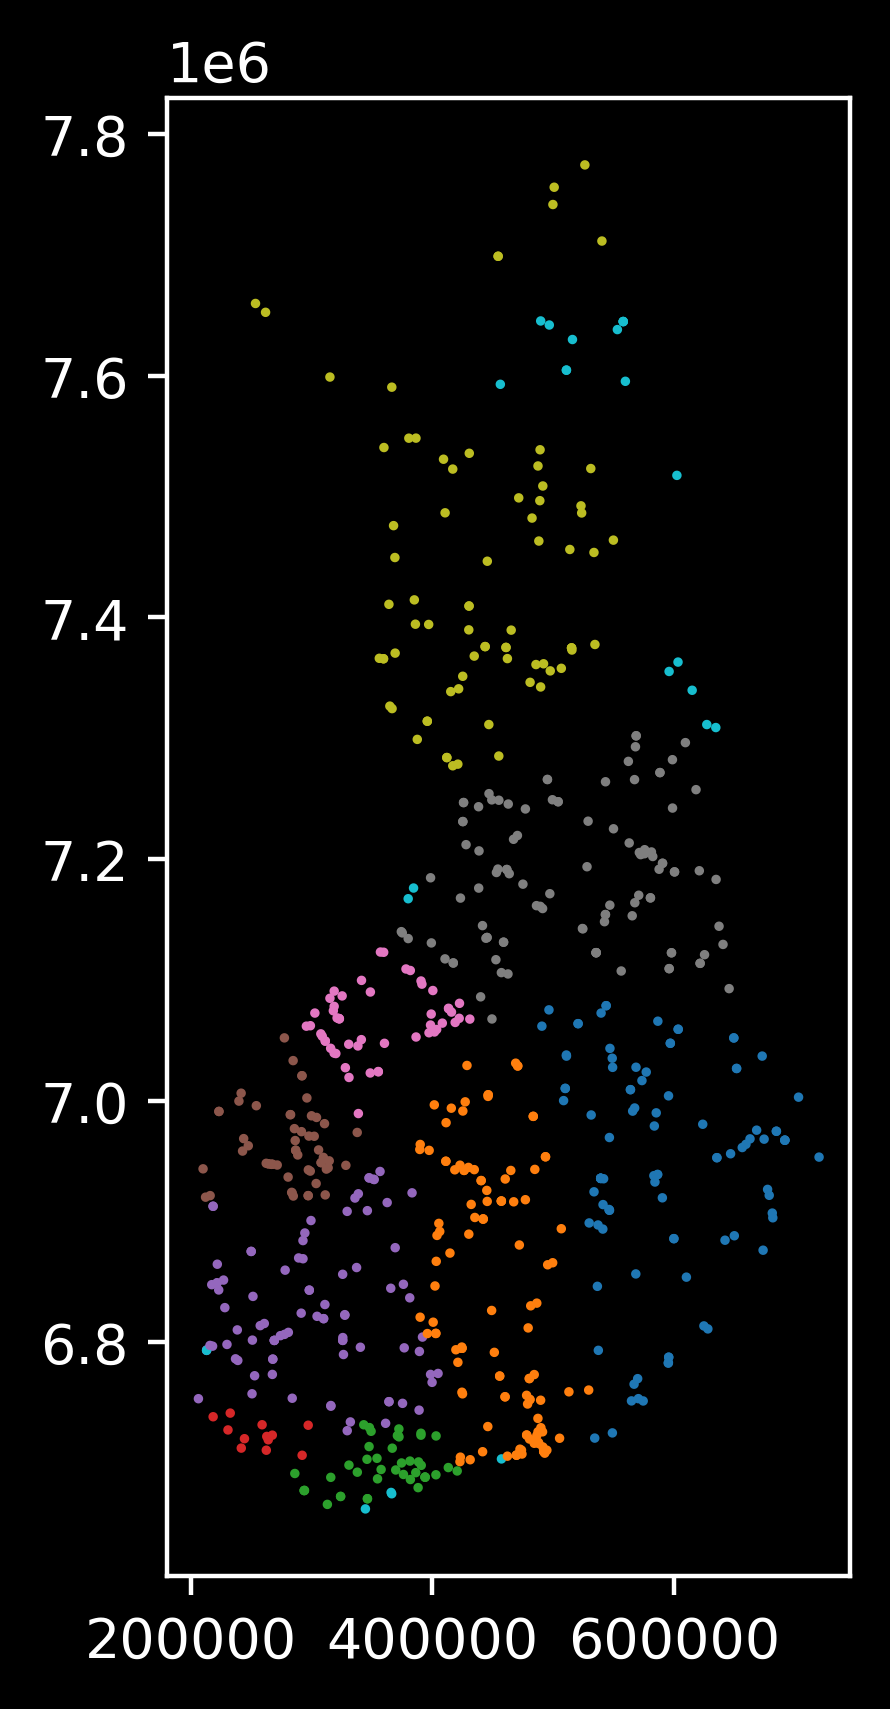

In [16]:
geoplaces.plot(column='H_PaaVesal_Id', markersize=0.5)

In [10]:
geoplaces.to_file('flow/measurement_locations.gpkg', driver="GPKG", layer="all")

In [17]:
paikka_ids = list(places.Paikka_Id)

flows = None
for place_id in tqdm(paikka_ids):
    flow_url = f"https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Virtaama?$filter=Paikka/Paikka_Id%20eq%20{place_id}"
    error_count = 0
    # The flow values are gathered to a temporary dataframe, that contains data of one location.
    place_flow = pd.DataFrame()
    while True:
        flow_batch = pd.DataFrame()
        try:
            response = requests.get(flow_url)
        except error as e:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with request:{e}")
            break

            
        if response.status_code == 200:
            content = response.json()
            keys = content.keys()
        else:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with status code {response.status_code}")
            break
            
        
        values = content['value']

        for i, value in enumerate(values):
            flow_batch.at[i, 'datetime'] = value['Aika'] # Aika == time
            flow_batch.at[i, str(place_id)] = float(value['Arvo']) # Arvo == value

        place_flow = pd.concat([place_flow, flow_batch], ignore_index=True)
        
        # is there still content left?
        if 'odata.nextLink' in keys:
            flow_url = content['odata.nextLink']
        else:
            break
        
    
    place_flow = place_flow.set_index(pd.DatetimeIndex(place_flow['datetime']), drop=True)
    place_flow = place_flow.drop('datetime', axis=1)

    if flows is None:
        flows = place_flow
    else:
        flows = pd.merge(flows, place_flow, on='datetime', how='outer')

dst_file_name = 'all_flows'
# uncomment the format you want. Parquet can handle datetime natively
flows.to_parquet(f"{dst_file_name}.parquet")
#flows_to_csv(f"{dst_file_name}.csv")

100%|███████████████████████████████████████| 673/673 [1:37:00<00:00,  8.65s/it]


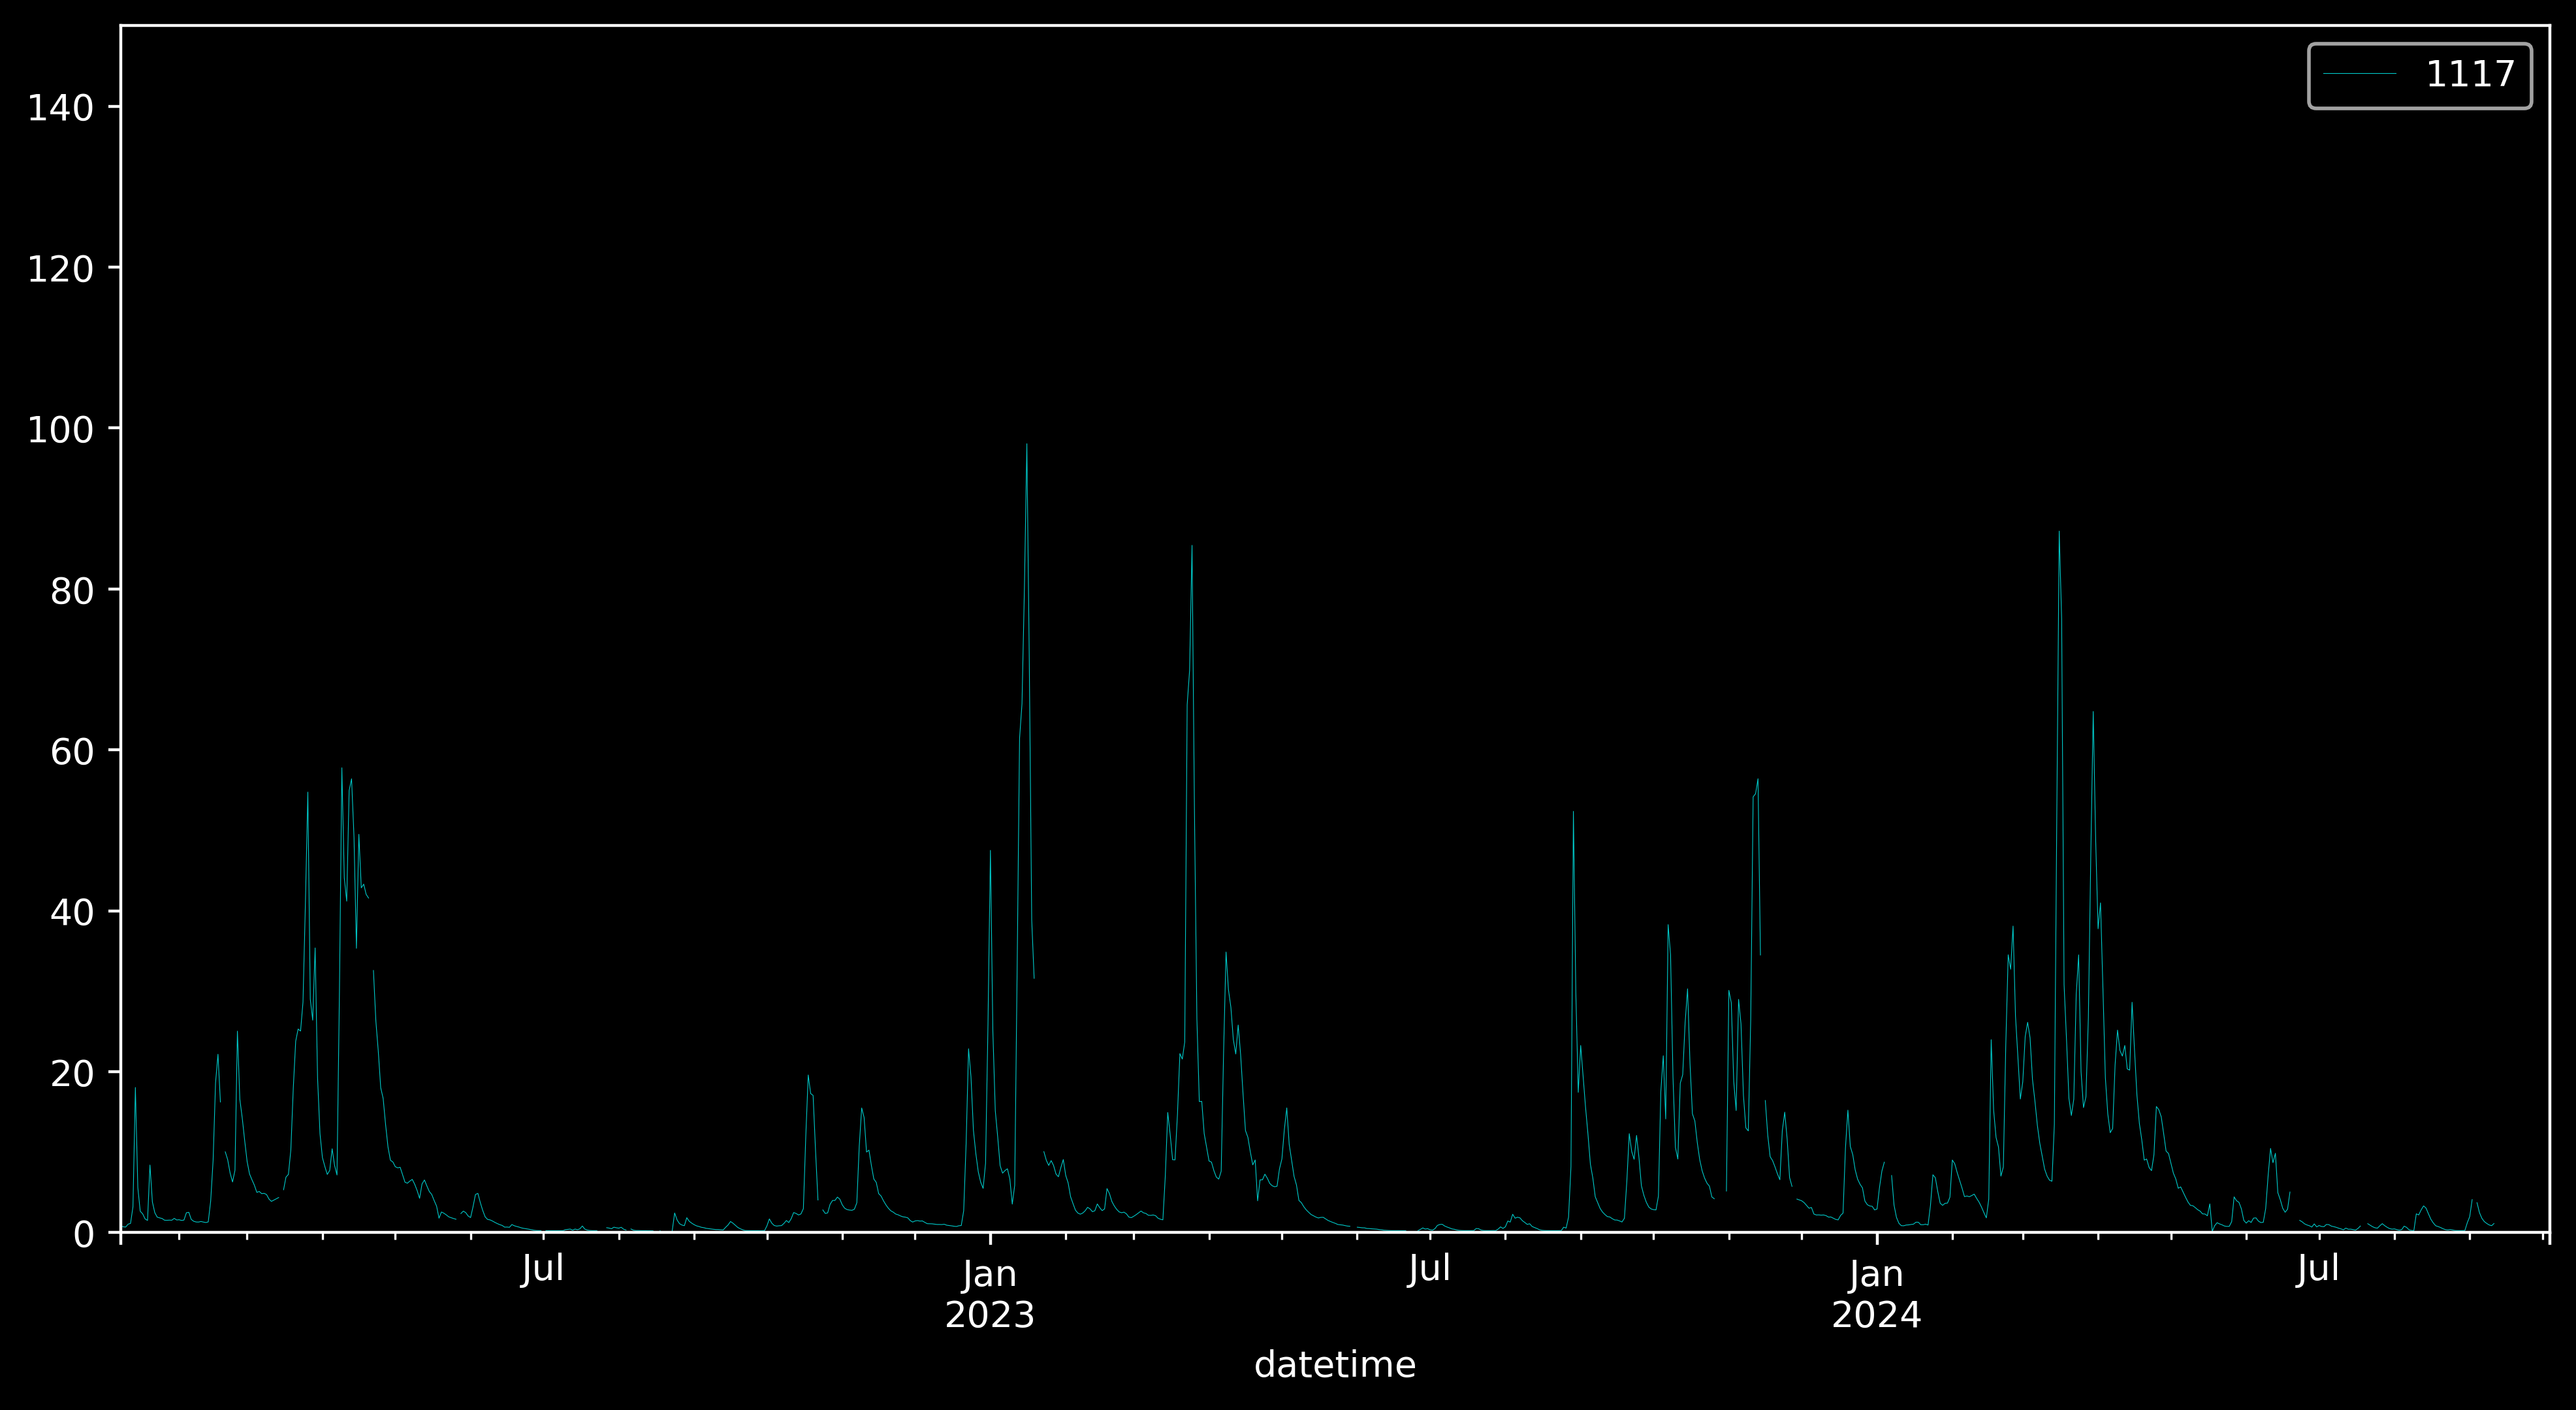

In [79]:
# Xlim units is days from 1.1.1970
# inarijoki, karigasniemi == 1409
# Aurajoki == 1117
lines = flows[['1117']].plot.line(figsize=(12, 6), xlim=(19000,20000), ylim=(0, 150), cmap='cool', alpha=0.8, linewidth=0.2)

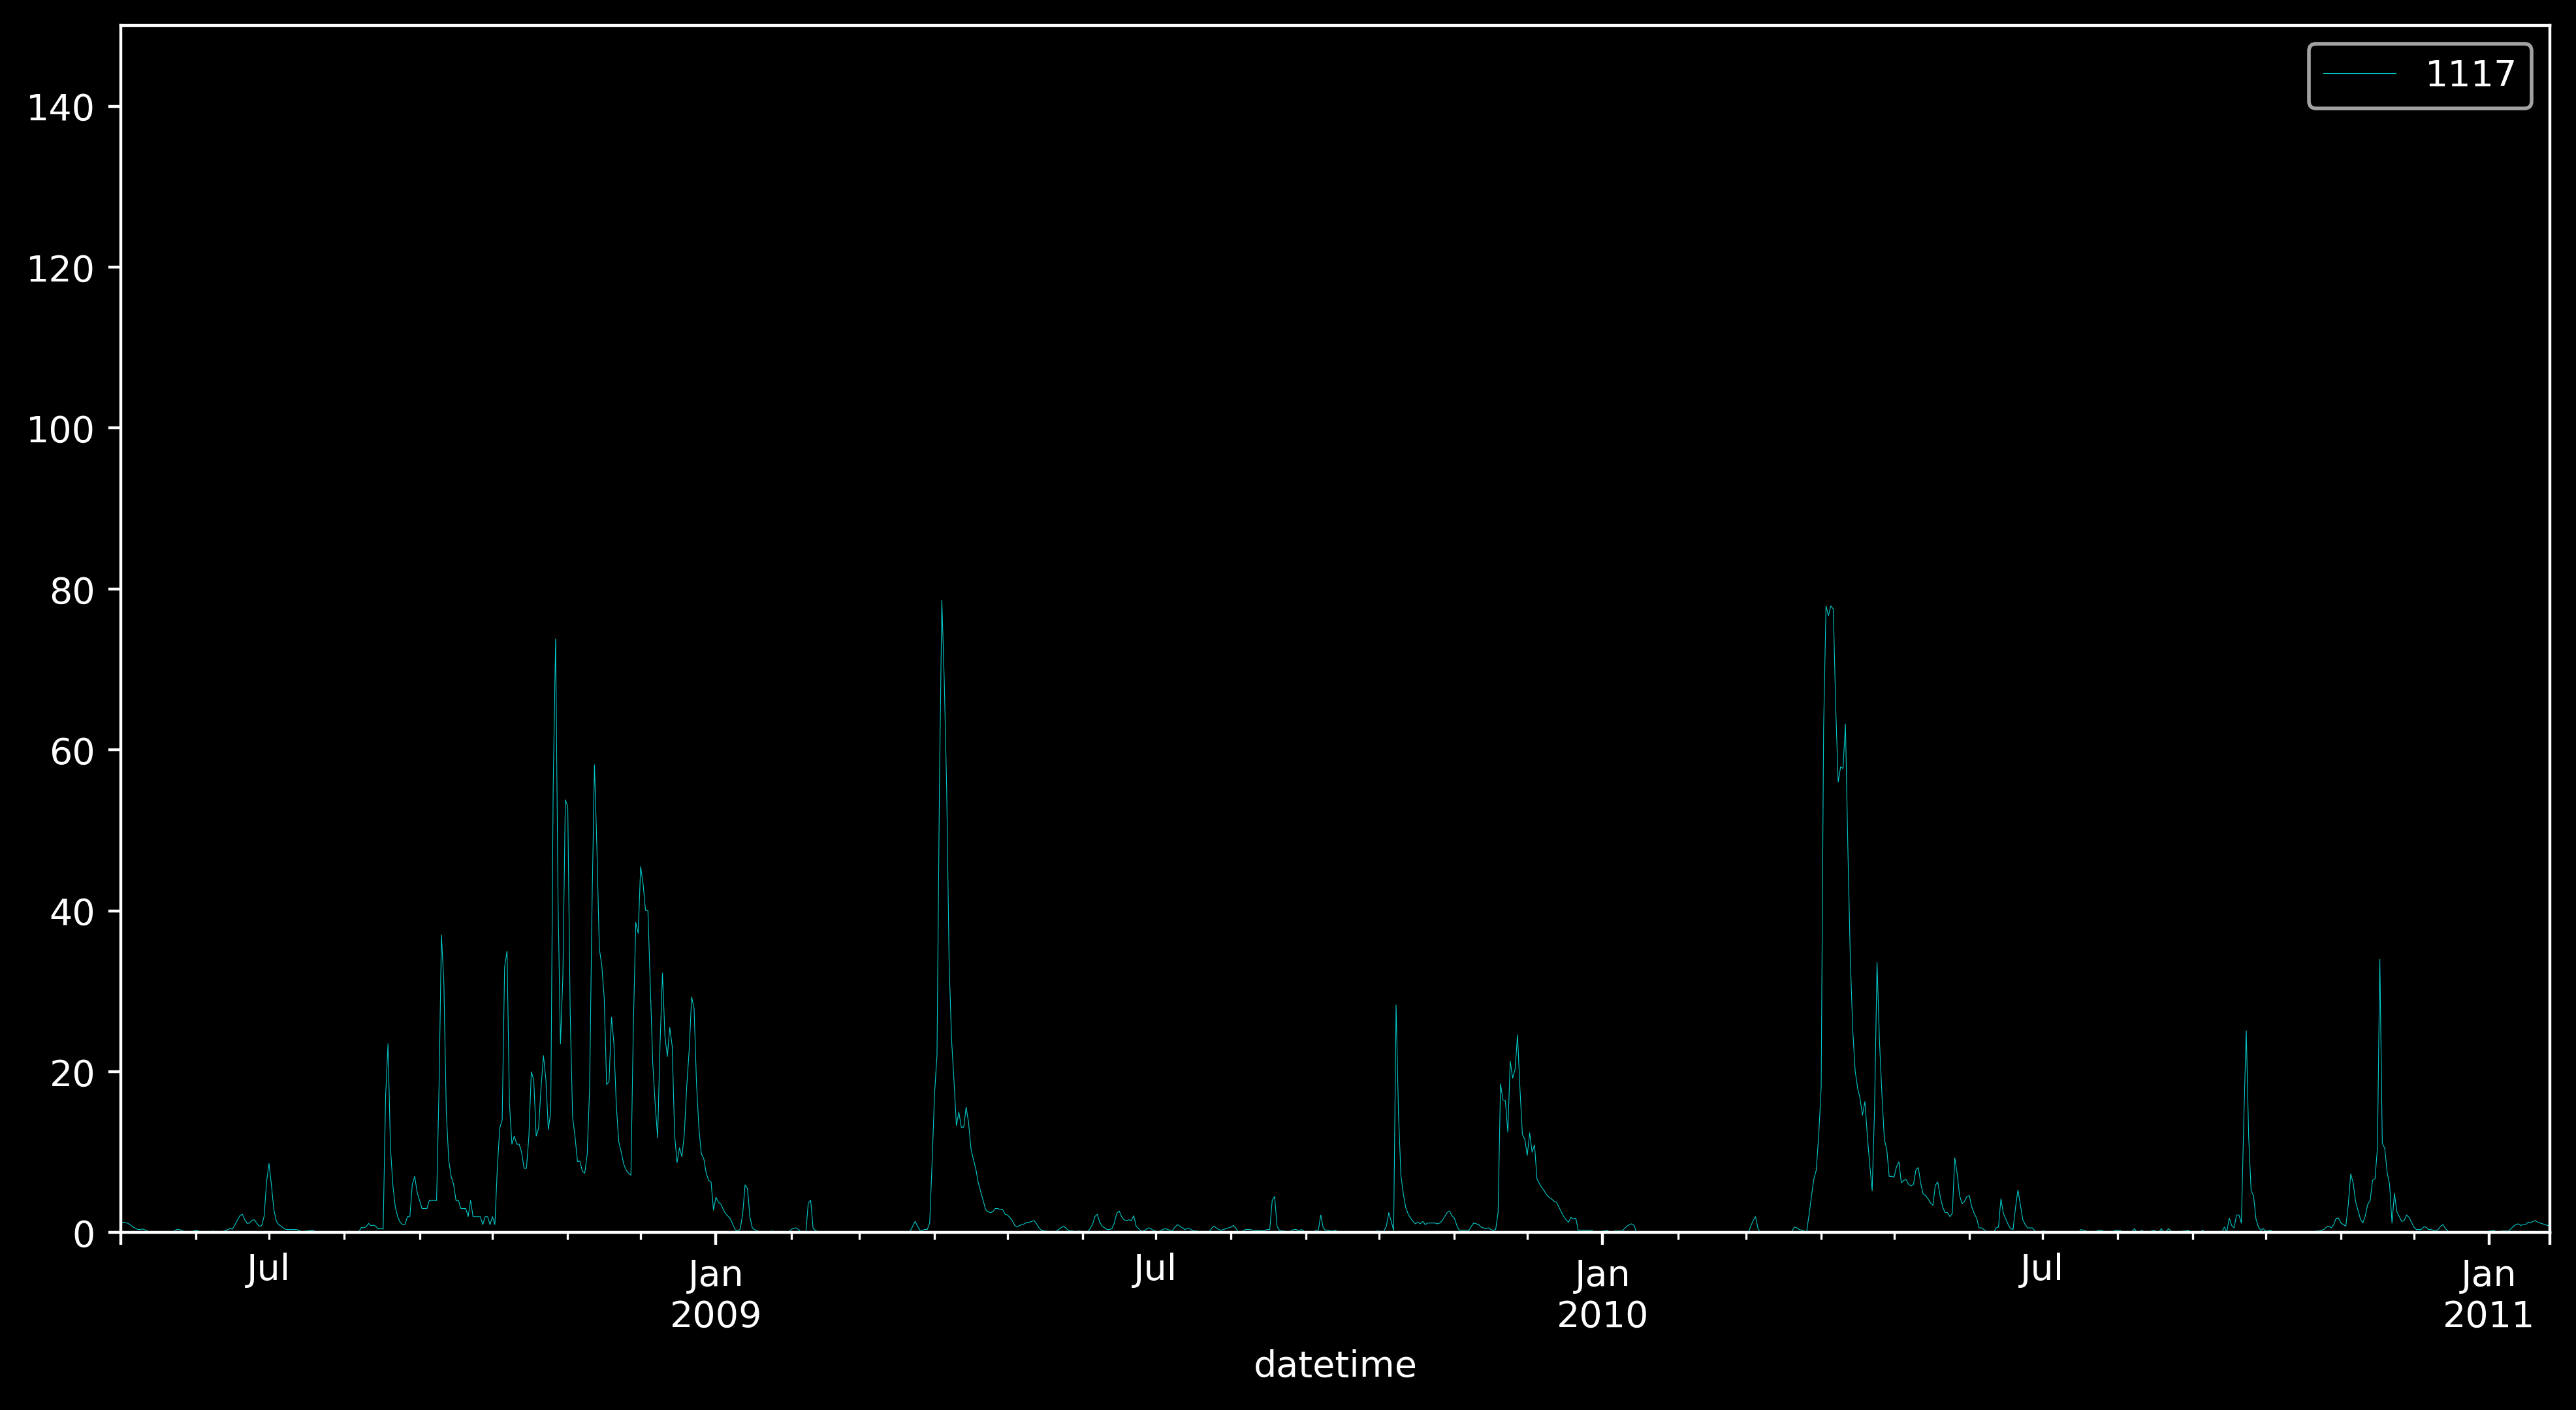

In [85]:
# Xlim units is days from 1.1.1970
# inarjoki, karigasniemi = 1409
# AUrajoki = 1117
lines = test_flows[['1117']].plot.line(figsize=(12, 6), xlim=(14000,15000), ylim=(0, 150), cmap='cool', alpha=0.8, linewidth=0.2)

In [26]:
pd.DatetimeIndex([values[0]['Aika']])

DatetimeIndex(['1959-01-01'], dtype='datetime64[ns]', freq=None)

In [11]:
content['odata.nextLink']

'https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Paikka?$filter=Virtaama%2Fany%28x%3A%20x%2FAika%20le%20datetime%272024-09-12T04%3A50%3A43.910Z%27%29&$skip=500'

In [32]:
test = place_flow
test = test.set_index(pd.DatetimeIndex(test['datetime']), drop=True)
test = test.drop('datetime', axis=1)
test

,flow
datetime,
1959-01-01,5.00
1959-01-02,7.80
1959-01-03,7.80
1959-01-04,7.00
1959-01-05,7.10
...,...
1960-05-10,24.70
1960-05-11,25.20
1960-05-12,25.30


In [27]:
values[0]

{'Paikka_Id': 894,
 'Aika': '1959-01-01T00:00:00',
 'Arvo': '5.00',
 'ArvoMin': None,
 'ArvoMax': None,
 'Lippu_id': None,
 'huomautus': None}

In [32]:
flows

,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,...,3892,3895,3900,3907,3915,3939,3944,3945,3952,3955,3956,3957,3960,3968,3975
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1847-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1847-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1847-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1847-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1847-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-09,1.0,4.74,0.74,2.52,NaN,NaN,4.22,53.75,NaN,55.85,NaN,2.18,NaN,1.68,2.61,...,7.98,9.17,8.61,NaN,0.26,NaN,0.09,0.86,0.54,0.34,0.25,NaN,0.0,1.43,1.45
2024-09-10,1.0,4.20,0.73,2.52,NaN,NaN,4.12,53.17,NaN,56.06,NaN,2.13,NaN,1.53,1.77,...,8.12,8.89,8.26,NaN,0.23,NaN,0.08,1.02,0.54,0.24,0.25,NaN,0.0,1.42,1.44
2024-09-11,1.0,4.53,0.80,2.52,NaN,NaN,4.04,52.96,NaN,55.73,NaN,2.08,NaN,1.41,0.00,...,8.14,8.85,7.83,NaN,0.22,NaN,0.08,0.93,0.54,1.53,0.18,NaN,0.0,1.40,1.38


In [8]:
paikat

,Paikka_Id,Suure_Id,H_Kunta_Id,KuntaNimi,Nro,Nimi,KoordYkPohj,KoordYkIta,KoordPkPohj,KoordPkIta,KoordLat,KoordLong,KoordTarkkuus,Karttalehti,Omistaja_Id,Tila_Id,Laitteisto_Id,H_Vesal_Id,VesalNimi,H_PaaVesal_Id,PaaVesalNimi,KoordErTmPohj,KoordErTmIta,Jarvi_Id,JarviNro,JarviNimi
0,894,2,167,Joensuu,0100150,Ruskeakoski,6929395,3677929,6924731,4522990,622536,302641,10,424107A,2,1,9,10,Loitimon la,1,Jänisjoki,6926492,677686,93,01.021.1.001,Melakko-Loitimo
1,895,2,848,Tohmajärvi,0101251,Vääräkoski,6905869,3682250,6901039,4526215,621250,303013,0,423208C,2,1,9,4,Jänisjoen keskiosan a,1,Jänisjoki,6902976,682005,18,01.011.1.018,Varislampi
2,896,2,260,Kitee,0201000,Kontturi,6879031,3674209,6874612,4516944,615838,301923,1,423105C,16,1,7,69,Kiteenjoen alaosan a,2,Tohmajoki,6876149,673968,742,02.021.1.001,Kamarahkonlampi
3,897,2,689,Rautjärvi,0300250,Juankoski,6816330,3625189,6814253,4465100,612604,292045,10,412302C,2,1,9,81,Simpelejärven alaosan la,3,Hiitolanjoki,6813473,624968,835,03.012.1.020,Konkanlampi
4,898,2,689,Rautjärvi,0300450,Kangaskoski,6813860,3628467,6811636,4468260,612440,292420,10,412302C,2,1,9,78,Kokkolanjoen a,3,Hiitolanjoki,6811004,628245,813,03.011.1.001,Lahnanen
5,899,2,422,Lieksa,0400510,"Jongunjoki, Viitakoski",7054821,3649961,7051283,4500910,633345,300105,0,434102A,16,2,None,340,Jongunjoen a,4,Vuoksi,7051867,649728,None,None,None
6,900,2,422,Lieksa,0400520,"Jongunjoki, Viitakoski",7054821,3649961,7051283,4500910,633345,300105,1,434102A,16,1,7,340,Jongunjoen a,4,Vuoksi,7051867,649728,None,None,None
7,901,2,422,Lieksa,0400600,"Lieksanjoki, Ruunaa",7039784,3673459,7035167,4523671,632502,302826,1,433209B,16,1,7,389,Ruunaanjärven a,4,Vuoksi,7036836,673217,8332,04.492.1.001,Polvijärvi
8,902,2,422,Lieksa,0400800,"Lieksanjoki, Höpöttäjänvirta",7029531,3652258,7025920,4502020,632006,300225,0,433202B,16,2,None,332,Lieksankosken a,4,Vuoksi,7026588,652025,6961,04.421.1.003,Riikolanlampi
9,903,2,422,Lieksa,0400850,"Lieksanjoki, Lieksankoski",7029531,3652258,7025920,4502020,632006,300225,10,433202B,2,1,9,332,Lieksankosken a,4,Vuoksi,7026588,652025,6961,04.421.1.003,Riikolanlampi


In [9]:
geopaikat

,Paikka_Id,Suure_Id,H_Kunta_Id,KuntaNimi,Nro,Nimi,KoordYkPohj,KoordYkIta,KoordPkPohj,KoordPkIta,KoordLat,KoordLong,KoordTarkkuus,Karttalehti,Omistaja_Id,Tila_Id,Laitteisto_Id,H_Vesal_Id,VesalNimi,H_PaaVesal_Id,PaaVesalNimi,KoordErTmPohj,KoordErTmIta,Jarvi_Id,JarviNro,JarviNimi,geometry
0,894,2,167,Joensuu,0100150,Ruskeakoski,6929395,3677929,6924731,4522990,622536,302641,10,424107A,2,1,9,10,Loitimon la,1,Jänisjoki,6926492,677686,93,01.021.1.001,Melakko-Loitimo,POINT (677686 6926492)
1,895,2,848,Tohmajärvi,0101251,Vääräkoski,6905869,3682250,6901039,4526215,621250,303013,0,423208C,2,1,9,4,Jänisjoen keskiosan a,1,Jänisjoki,6902976,682005,18,01.011.1.018,Varislampi,POINT (682005 6902976)
2,896,2,260,Kitee,0201000,Kontturi,6879031,3674209,6874612,4516944,615838,301923,1,423105C,16,1,7,69,Kiteenjoen alaosan a,2,Tohmajoki,6876149,673968,742,02.021.1.001,Kamarahkonlampi,POINT (673968 6876149)
3,897,2,689,Rautjärvi,0300250,Juankoski,6816330,3625189,6814253,4465100,612604,292045,10,412302C,2,1,9,81,Simpelejärven alaosan la,3,Hiitolanjoki,6813473,624968,835,03.012.1.020,Konkanlampi,POINT (624968 6813473)
4,898,2,689,Rautjärvi,0300450,Kangaskoski,6813860,3628467,6811636,4468260,612440,292420,10,412302C,2,1,9,78,Kokkolanjoen a,3,Hiitolanjoki,6811004,628245,813,03.011.1.001,Lahnanen,POINT (628245 6811004)
5,899,2,422,Lieksa,0400510,"Jongunjoki, Viitakoski",7054821,3649961,7051283,4500910,633345,300105,0,434102A,16,2,None,340,Jongunjoen a,4,Vuoksi,7051867,649728,None,None,None,POINT (649728 7051867)
6,900,2,422,Lieksa,0400520,"Jongunjoki, Viitakoski",7054821,3649961,7051283,4500910,633345,300105,1,434102A,16,1,7,340,Jongunjoen a,4,Vuoksi,7051867,649728,None,None,None,POINT (649728 7051867)
7,901,2,422,Lieksa,0400600,"Lieksanjoki, Ruunaa",7039784,3673459,7035167,4523671,632502,302826,1,433209B,16,1,7,389,Ruunaanjärven a,4,Vuoksi,7036836,673217,8332,04.492.1.001,Polvijärvi,POINT (673217 7036836)
8,902,2,422,Lieksa,0400800,"Lieksanjoki, Höpöttäjänvirta",7029531,3652258,7025920,4502020,632006,300225,0,433202B,16,2,None,332,Lieksankosken a,4,Vuoksi,7026588,652025,6961,04.421.1.003,Riikolanlampi,POINT (652025 7026588)
9,903,2,422,Lieksa,0400850,"Lieksanjoki, Lieksankoski",7029531,3652258,7025920,4502020,632006,300225,10,433202B,2,1,9,332,Lieksankosken a,4,Vuoksi,7026588,652025,6961,04.421.1.003,Riikolanlampi,POINT (652025 7026588)
